# Tableau - Python - LOD Cases
- LOD (Level of Detail) in Tableau is a feature that lets you perform calculations at a different level of granularity than what’s currently displayed in the visualization. This allows you to create calculations independent of the view’s dimensions.
- 


## Types of LOD
1. FIXED
    - Calculates values at a specified level, regardless of the dimensions in the view.
    - Syntax: {FIXED [Region] : SUM([Sales])}
    - Example: Calculate total sales for each region even if the view shows city-level data.
2. INCLUDE
    - Adds dimensions to the current level of detail.
    - Syntax: {INCLUDE [Customer Name] : SUM([Sales])}
    - Example: Calculate customer-level sales and then aggregate them to the current view.
3. EXCLUDE
   - Removes one or more dimensions from the current level of detail.
   - Syntax : {EXCLUDE [Category] : SUM([Sales])}
   - Example: Calculate total sales without considering the Category dimension, even if Category is in the view.
## A simple way to remember them:
* FIXED = Ignore the view; calculate at the dimensions you specify.
* INCLUDE = Add extra dimensions to the calculation.
* EXCLUDE = Remove dimensions from the calculatio

## Tableau - S1x
- Suppose your view displays Sales by State (S1A)
- but you want to compare each state’s sales with the overall company sales.
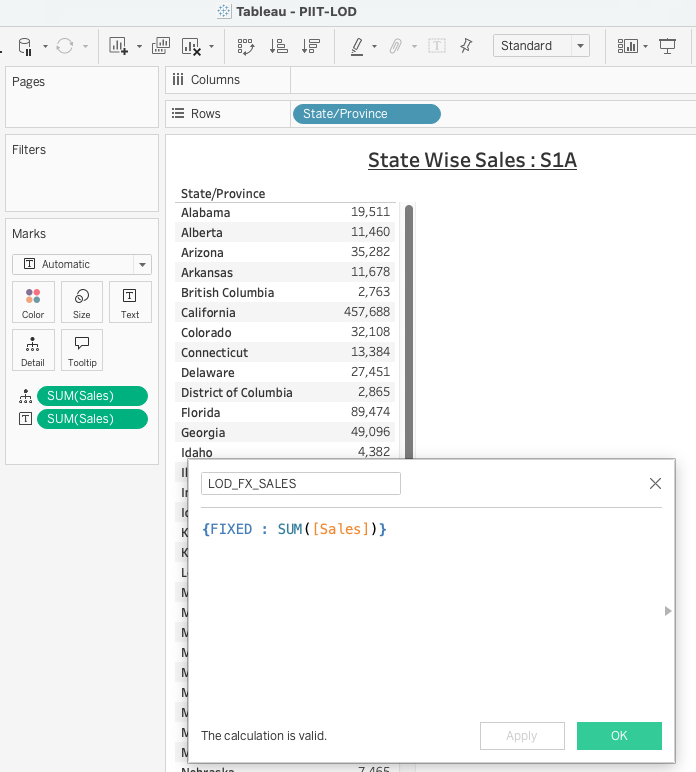
- Create a Calculated Field : LOD_FX_SALES -> {FIXED : SUM([Sales])}
- This returns the total sales for the entire dataset, regardless of the dimensions in the view.
- Now we can find difference between State Sales and Total Sales.
    - create a calculated field
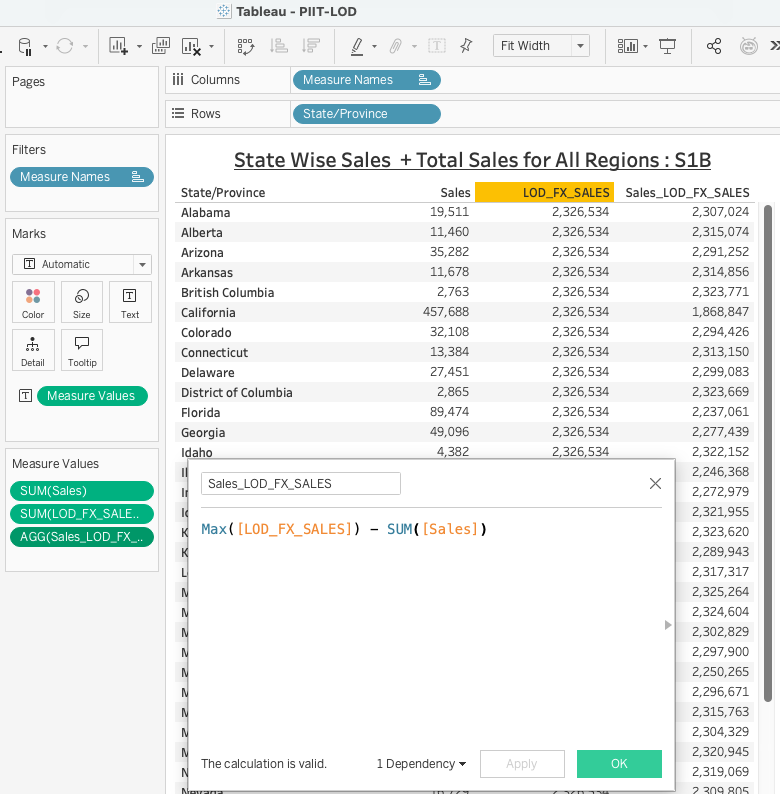 
- Notes
    - SUM([Sales]) is an aggregate.
    - [LOD_FX_SALES] is treated as a row-level field after it has been materialized.
    - Wrapping it in MAX() (or MIN()) makes it an aggregate too, so Tableau is happy.

## Superstore Data - when use LOD
* Calculate customer lifetime value.
* Find first or last purchase date.
* Compute regional totals while viewing city-level data.
* Calculate percentages of total.
* Perform calculations at a different granularity than the current visualization.

# Tableau - Python : LOD Equivalence
- equivalent of LOD 
    - Tableau : { FIXED : SUM([Sales]) }
    - Python : df.groupby("State")["Sales"].transform("sum")

In [ ]:
## Libraries
import pandas as pd
import matplotlib.pyplot as plt

## Data

In [3]:
csv_orders_url = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
orders = pd.read_csv(csv_orders_url)
orders.shape

(10194, 21)

In [4]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,03/01/23,07/01/23,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,04/01/23,08/01/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,04/01/23,08/01/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,04/01/23,08/01/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,05/01/23,12/01/23,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [76]:
# specific columns
selc1 = ['Order ID','Region', 'State/Province', 'Category','Sub-Category','Customer ID','Customer Name','Sales']
orders[selc1].head()

,Order ID,Region,State/Province,Category,Sub-Category,Customer ID,Customer Name,Sales
0,US-2023-103800,Central,Texas,Office Supplies,Paper,DP-13000,Darren Powers,16.448
1,US-2023-112326,Central,Illinois,Office Supplies,Binders,PO-19195,Phillina Ober,3.540
2,US-2023-112326,Central,Illinois,Office Supplies,Labels,PO-19195,Phillina Ober,11.784
3,US-2023-112326,Central,Illinois,Office Supplies,Storage,PO-19195,Phillina Ober,272.736
4,US-2023-141817,East,Pennsylvania,Office Supplies,Art,MB-18085,Mick Brown,19.536


In [77]:
# Make a copy of selected Column Data
orders1 = orders[selc1].copy()
orders1.head()

,Order ID,Region,State/Province,Category,Sub-Category,Customer ID,Customer Name,Sales
0,US-2023-103800,Central,Texas,Office Supplies,Paper,DP-13000,Darren Powers,16.448
1,US-2023-112326,Central,Illinois,Office Supplies,Binders,PO-19195,Phillina Ober,3.540
2,US-2023-112326,Central,Illinois,Office Supplies,Labels,PO-19195,Phillina Ober,11.784
3,US-2023-112326,Central,Illinois,Office Supplies,Storage,PO-19195,Phillina Ober,272.736
4,US-2023-141817,East,Pennsylvania,Office Supplies,Art,MB-18085,Mick Brown,19.536


## LOD-1A : State Wise Sales and Total Sales


In [78]:
## Lets use only selected Columns
regionSales = orders1[['Order ID','State/Province','Sales']]
regionSales.head(2)

,Order ID,State/Province,Sales
0,US-2023-103800,Texas,16.448
1,US-2023-112326,Illinois,3.540


In [79]:
s1a = regionSales.groupby('State/Province')['Sales'].agg('sum').round().reset_index()
s1a.head(2)

,State/Province,Sales
0,Alabama,19511.0
1,Alberta,11460.0


In [80]:
s1a['TOTAL_SALES'] = s1a['Sales'].sum()
s1a.head(2)

,State/Province,Sales,TOTAL_SALES
0,Alabama,19511.0,2326534.0
1,Alberta,11460.0,2326534.0


In [81]:
# % of state Sales from Total Sales
s1a['PercSales'] = (100 * s1a['Sales']/s1a['TOTAL_SALES']).round()
s1a.head()

,State/Province,Sales,TOTAL_SALES,PercSales
0,Alabama,19511.0,2326534.0,1.0
1,Alberta,11460.0,2326534.0,0.0
2,Arizona,35282.0,2326534.0,2.0
3,Arkansas,11678.0,2326534.0,1.0
4,British Columbia,2763.0,2326534.0,0.0


In [82]:
orders1.head(2)
#now add a column of State State 
s1b = orders1.copy()
s1b.head()

,Order ID,Region,State/Province,Category,Sub-Category,Customer ID,Customer Name,Sales
0,US-2023-103800,Central,Texas,Office Supplies,Paper,DP-13000,Darren Powers,16.448
1,US-2023-112326,Central,Illinois,Office Supplies,Binders,PO-19195,Phillina Ober,3.540
2,US-2023-112326,Central,Illinois,Office Supplies,Labels,PO-19195,Phillina Ober,11.784
3,US-2023-112326,Central,Illinois,Office Supplies,Storage,PO-19195,Phillina Ober,272.736
4,US-2023-141817,East,Pennsylvania,Office Supplies,Art,MB-18085,Mick Brown,19.536


In [83]:
s1b['STATE_SALES'] = s1b.groupby('State/Province', as_index=False)['Sales'].transform('sum').round()
s1b['TOTAL_SALES'] = s1b['Sales'].sum().round()
s1b.head(2)

,Order ID,Region,State/Province,Category,Sub-Category,Customer ID,Customer Name,Sales,STATE_SALES,TOTAL_SALES
0,US-2023-103800,Central,Texas,Office Supplies,Paper,DP-13000,Darren Powers,16.448,170188.0,2326534.0
1,US-2023-112326,Central,Illinois,Office Supplies,Binders,PO-19195,Phillina Ober,3.540,80166.0,2326534.0


In [84]:
s1b[['State/Province','Order ID', 'Sales','STATE_SALES','TOTAL_SALES']].sort_values(['State/Province'], ascending=True)

,State/Province,Order ID,Sales,STATE_SALES,TOTAL_SALES
2690,Alabama,US-2024-104941,32.400,19511.0,2326534.0
336,Alabama,US-2023-124023,8.960,19511.0,2326534.0
7687,Alabama,US-2026-127803,26.160,19511.0,2326534.0
341,Alabama,US-2023-118997,1215.920,19511.0,2326534.0
2692,Alabama,US-2024-104941,899.970,19511.0,2326534.0
...,...,...,...,...,...
2156,Wisconsin,US-2024-154326,134.970,32115.0,2326534.0
7265,Wisconsin,US-2026-155880,1526.560,32115.0,2326534.0
6520,Wisconsin,US-2025-114489,1951.840,32115.0,2326534.0
6525,Wisconsin,US-2025-114489,171.550,32115.0,2326534.0


In [85]:
orders1.groupby('State/Province', as_index=False)['Sales'].sum().round().assign(Total_Sales_LOD=lambda x: x['Sales'].sum())

,State/Province,Sales,Total_Sales_LOD
0,Alabama,19511.0,2326534.0
1,Alberta,11460.0,2326534.0
2,Arizona,35282.0,2326534.0
3,Arkansas,11678.0,2326534.0
4,British Columbia,2763.0,2326534.0
5,California,457688.0,2326534.0
6,Colorado,32108.0,2326534.0
7,Connecticut,13384.0,2326534.0
8,Delaware,27451.0,2326534.0
9,District of Columbia,2865.0,2326534.0


## LOD.F2 - Fixed - Region sales - Total Sales

In [86]:
orders1.head()

,Order ID,Region,State/Province,Category,Sub-Category,Customer ID,Customer Name,Sales
0,US-2023-103800,Central,Texas,Office Supplies,Paper,DP-13000,Darren Powers,16.448
1,US-2023-112326,Central,Illinois,Office Supplies,Binders,PO-19195,Phillina Ober,3.540
2,US-2023-112326,Central,Illinois,Office Supplies,Labels,PO-19195,Phillina Ober,11.784
3,US-2023-112326,Central,Illinois,Office Supplies,Storage,PO-19195,Phillina Ober,272.736
4,US-2023-141817,East,Pennsylvania,Office Supplies,Art,MB-18085,Mick Brown,19.536


In [87]:
s2a = orders1.groupby('Region')['Sales'].agg('sum').round().reset_index(). \
    assign(TotalSales=lambda x: x['Sales'].sum().round()) 
s2a

,Region,Sales,TotalSales
0,Central,503171.0,2326535.0
1,East,691828.0,2326535.0
2,South,391722.0,2326535.0
3,West,739814.0,2326535.0


## LOD.F3 - Each Order with Total Customer Sales
- OrderID : Customer ID : Customer Name : Sales :: Total Customer Sales
- Tableau LOD equivalent: # { FIXED [Customer Name] : SUM([Sales]) }
    - For each customer, show total sales for Customer
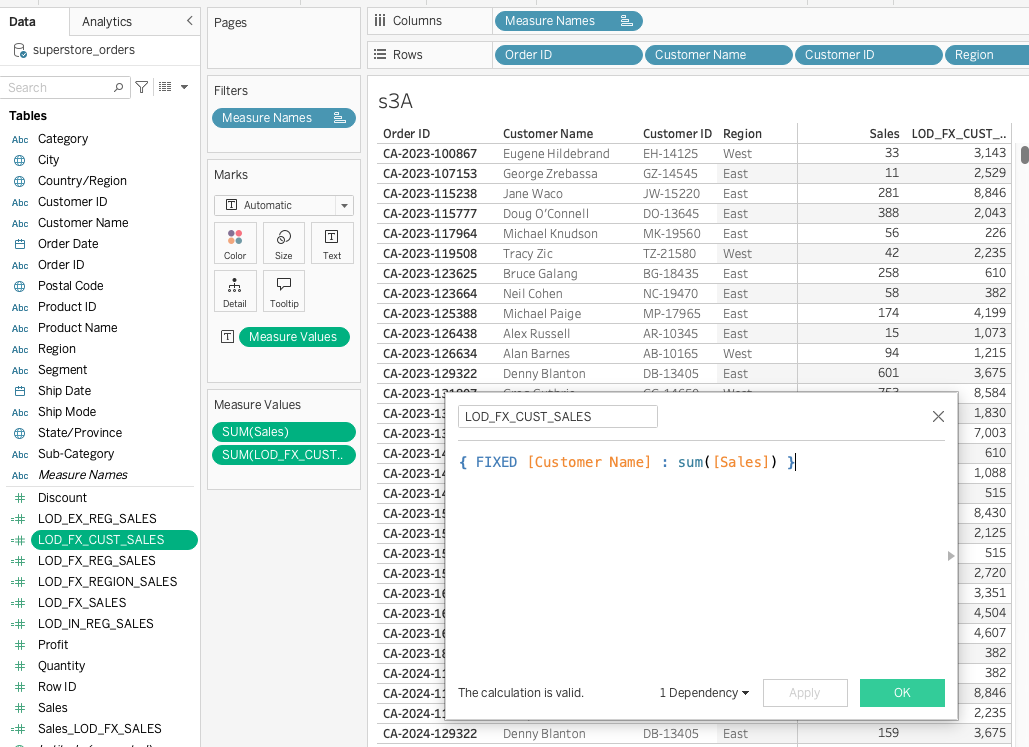

In [105]:
s3 = orders1[['Order ID','Customer ID','Customer Name','Region','Sales']].copy()
s3.head()

,Order ID,Customer ID,Customer Name,Region,Sales
0,US-2023-103800,DP-13000,Darren Powers,Central,16.448
1,US-2023-112326,PO-19195,Phillina Ober,Central,3.540
2,US-2023-112326,PO-19195,Phillina Ober,Central,11.784
3,US-2023-112326,PO-19195,Phillina Ober,Central,272.736
4,US-2023-141817,MB-18085,Mick Brown,East,19.536


In [106]:
# Agg - Returns one row per customer
s3.groupby(['Customer ID','Customer Name'])['Sales'].agg('sum').round().reset_index()

,Customer ID,Customer Name,Sales
0,AA-10315,Alex Avila,5564.0
1,AA-10375,Allen Armold,1056.0
2,AA-10480,Andrew Allen,1791.0
3,AA-10645,Anna Andreadi,5087.0
4,AB-10015,Aaron Bergman,886.0
...,...,...,...
799,XP-21865,Xylona Preis,2503.0
800,YC-21895,Yoseph Carroll,5454.0
801,YS-21880,Yana Sorensen,6720.0
802,ZC-21910,Zuschuss Carroll,8026.0


In [107]:
# using Transform # returns the same number of rows- Series - single column values, 
#indexed by customer name: columns - index, value -> Series which can joined to DF
(s3.groupby('Customer Name')['Sales'].transform('sum'))

0        1050.636
1        1056.858
2        1056.858
3        1056.858
4        1428.231
           ...   
10189    2493.214
10190    1643.255
10191     303.948
10192    2493.214
10193    1087.916
Name: Sales, Length: 10194, dtype: float64

In [108]:
s3['Customer Total Sales'] = (s3.groupby(['Customer ID','Customer Name'])['Sales'].transform('sum').round())
s3.sort_values(by='Order ID').head()

,Order ID,Customer ID,Customer Name,Region,Sales,Customer Total Sales
1379,CA-2023-100867,EH-14125,Eugene Hildebrand,West,32.700,3143.0
1240,CA-2023-107153,GZ-14545,George Zrebassa,East,10.688,2529.0
61,CA-2023-115238,JW-15220,Jane Waco,East,24.300,8846.0
62,CA-2023-115238,JW-15220,Jane Waco,East,9.480,8846.0
63,CA-2023-115238,JW-15220,Jane Waco,East,31.400,8846.0


### Now add Total Sales of each Customer for the Region of the row
- Tableau LOD equivalent: # { FIXED [Customer Name],[Region]: SUM([Sales]) }
    - For each customer, show total sales by each region and also all regions and for each region
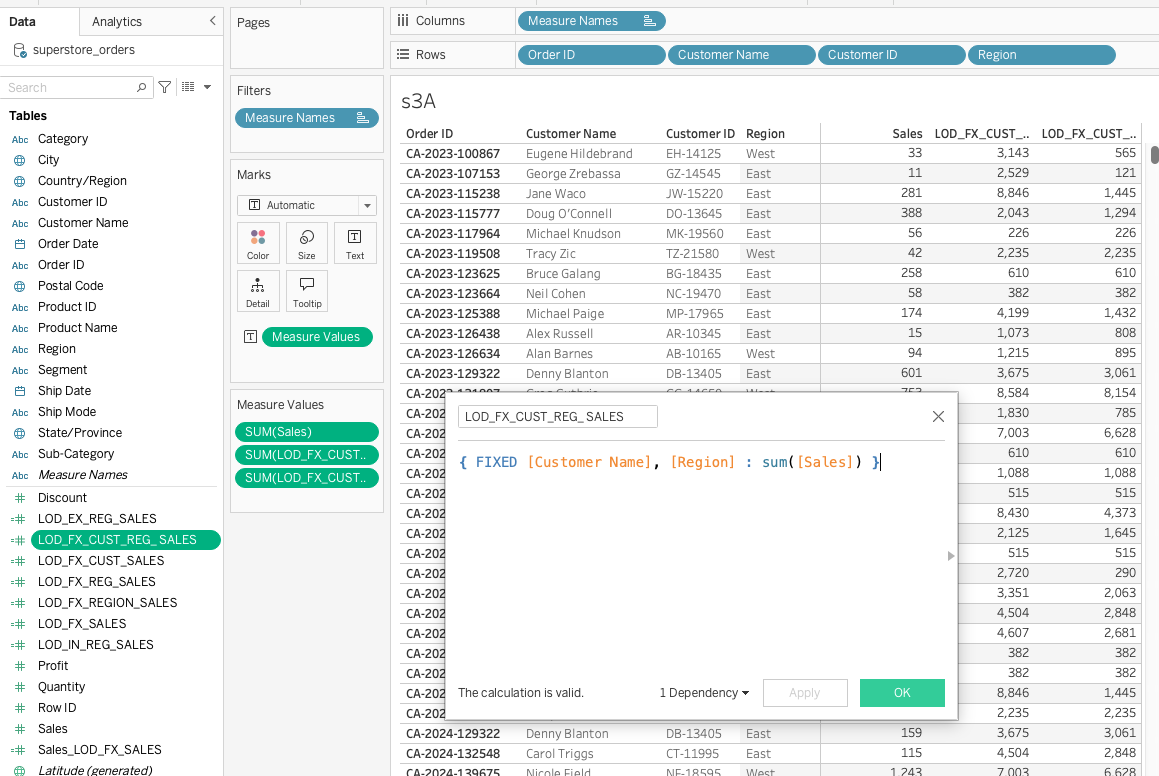

In [110]:
s3.groupby(['Customer Name', 'Region'])['Sales'].agg('sum').reset_index()

,Customer Name,Region,Sales
0,Aaron Bergman,Central,576.564
1,Aaron Bergman,West,309.592
2,Aaron Hawkins,East,330.126
3,Aaron Hawkins,South,86.450
4,Aaron Hawkins,West,1328.124
...,...,...,...
2503,Zuschuss Carroll,South,1470.892
2504,Zuschuss Carroll,West,2641.089
2505,Zuschuss Donatelli,Central,331.080
2506,Zuschuss Donatelli,South,856.664


In [112]:
s3['Customer Region Sales'] = s3.groupby(['Customer Name', 'Region'])['Sales'].transform('sum').round()
s3.sort_values(by='Order ID').head()

,Order ID,Customer ID,Customer Name,Region,Sales,Customer Total Sales,Customer Region Sales
1379,CA-2023-100867,EH-14125,Eugene Hildebrand,West,32.700,3143.0,565.0
1240,CA-2023-107153,GZ-14545,George Zrebassa,East,10.688,2529.0,121.0
61,CA-2023-115238,JW-15220,Jane Waco,East,24.300,8846.0,1445.0
62,CA-2023-115238,JW-15220,Jane Waco,East,9.480,8846.0,1445.0
63,CA-2023-115238,JW-15220,Jane Waco,East,31.400,8846.0,1445.0


## Graphs 

### Tableau
- Plot - 1 : Total Sales by Region
    - Drag
        - Region to Columns
        - Sales to Rows
- Plot - 2 : Top 10 Customers by Sales
    - Drag
        - Customer Name to Rows
        - Sales to Columns
    - Sort : Descending on Sales
    - Filter : Top 10 by Sales
- Plot - 3 : Customer Total Sales using LOD
    - Calculated Field
        - { FIXED [Customer Name ] : SUM([Sales]) } 

### Python

In [ ]:
# Plot1
region_sales = (orders1.groupby("Region")["Sales"].sum().sort_values(ascending=False))
#ax = region_sales.plot( kind="bar", figsize=(8,5))
#plt.figure(figsize=(8, 5))
ax = region_sales.plot( kind="bar", figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
# Add value labels
for p in ax.patches:
    ax.annotate( f'${p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),ha='center', va='bottom'  )
plt.tight_layout()
plt.show();

In [ ]:
# Plot 2
top_customers = (orders1.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10).sort_values())
#plt.figure(figsize=(10, 6))
ax = top_customers.plot( kind="barh",  figsize=(10,6))
top_customers.sort_values().plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
# Add value labels
for p in ax.patches:
    ax.annotate( f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center' )
plt.tight_layout()
plt.show();

In [ ]:
orders1[["Customer Name", "Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10)

In [ ]:
orders1.head()

In [ ]:
orders1[orders1.duplicated()]

In [ ]:
# Plot 3 - Tableau way of plotting
customer_lod_plot = ( orders1[["Customer Name", "Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10))
plt.figure(figsize=(10, 6))
plt.barh(customer_lod_plot["Customer Name"][::-1],  customer_lod_plot["Customer Total Sales"][::-1])
plt.title("Top 10 Customers by LOD Sales")
plt.xlabel("Customer Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show();

In [ ]:
customer_lod = ( orders1[["Customer Name","Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10).sort_values("Customer Total Sales"))
ax = customer_lod.plot( x="Customer Name",  y="Customer Total Sales", kind="barh", figsize=(10,6), legend=False)
plt.title("Top 10 Customers by Total Sales (LOD)")
# Labels
for p in ax.patches:
    ax.annotate(
        f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height()/2),   ha='left', va='center'  )
plt.tight_layout()
plt.show()

## commands : Table-> Python
- show Mark Labels -ax.annotate()
- FIXED LOD - groupby().transform()
- Sort Descending - sort_values(ascending=False)
- Top N Filter - .head(N)
- Horizontal Bars - kind='barh'